# Task 1. Face Alignment (Stacked Hourglass Network) — Kaggle Notebooks

Задание (4 балла): подготовить датасет, реализовать и обучить Stacked Hourglass Network для поиска
5 ключевых точек лица, реализовать функцию, которая по фотографии лица возвращает выровненное лицо
на основе найденных точек (вторая часть пайплайна face recognition).

## Как экономить бесплатную GPU-квоту Kaggle (30 ч/неделю)

Ноутбук разбит на две части:

- **Фаза A (CPU)** — скачивание датасета, отбор изображений, кроп по bbox. Чистый `pandas`/`cv2`,
  GPU не нужен. В `Settings → Accelerator` выберите **None**.
- **Фаза B (GPU)** — обучение Stacked Hourglass и инференс. В `Settings → Accelerator` выберите
  **GPU T4 x2** (или P100).

Смена ускорителя в Kaggle перезапускает сессию редактирования этого же ноутбука — как правило,
`/kaggle/working` при этом сохраняется (это персистентная рабочая папка ноутбука), но для надёжности
после Фазы A нажмите **Save Version** (Quick Save) — тогда данные точно не потеряются, даже если
сессия истечёт по таймауту простоя.

**Для Task 2:** после того как этот ноутбук обучит модель, нажмите **Save Version** — это сделает
файлы из `/kaggle/working` (веса Hourglass, `selected_dataset.csv`) доступными как источник данных
для другого ноутбука через `+ Add Data → Notebook Output Files → (этот ноутбук)`.


In [1]:
import os

WORKING_DIR = '/kaggle/working'
print('Рабочая папка Kaggle:', WORKING_DIR, '- содержимое сохраняется между сессиями этого ноутбука')


Рабочая папка Kaggle: /kaggle/working - содержимое сохраняется между сессиями этого ноутбука


In [2]:
import os
import math
import shutil
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


---
# Фаза A (CPU) — подготовка датасета

Этот раздел не требует GPU — Если ещё не переключили среду выполнения на CPU — самое время
(`Settings → Accelerator → None`), это сэкономит GPU-квоту на время скачивания и обработки ~10 500
изображений.


## 1.1 Подготовка датасета

CelebA "In the Wild" поставляется с файлами разметки:
- `list_bbox_celeba.txt` — bbox лица на каждой картинке;
- `list_landmarks_celeba.txt` — 5 ключевых точек в исходных (in-the-wild) координатах;
- `list_attr_celeba.txt` — бинарные атрибуты (пол, очки, размытость и т.д.);
- `identity_CelebA.txt` — id личности (понадобится в Task 2).

**Критерий отбора 10 000+ изображений:** исключаем сильно размытые фото (`Blurry == 1`), берём случайную
выборку из отфильтрованного множества с ограничением не более 30 фото на личность — чтобы сохранить
разнообразие ракурсов/лиц и не перекоситься в сторону "медийных" личностей с большим числом фото.
Для Task 1 распределение по личностям не критично (в отличие от Task 2) — модели важно увидеть
разнообразные лица, а не конкретных людей.

**Скачивание.** Официальный архив `img_celeba.7z` на Google Drive разбит на 14 частей и часто отдаёт
`Quota exceeded`. Используем зеркало на Kaggle (`kevinpatel04/celeba-original-wild-images`) — качается
единым архивом. В этом зеркале нет файлов landmarks/identity — их отдельно докачиваем с Google Drive
(это маленькие текстовые файлы, `Quota exceeded` на них практически не бывает). Картинки в архиве
разложены по 21 вложенной папке `Part N/Part N/*.jpg` — строим единый индекс имя→путь.


In [4]:
!pip install -q kagglehub gdown

import kagglehub
import gdown

KAGGLE_DATASET = 'kevinpatel04/celeba-original-wild-images'
kaggle_path = kagglehub.dataset_download(KAGGLE_DATASET)
print('Датасет скачан в:', kaggle_path)

CELEBA_ROOT = 'data/celeba'
os.makedirs(CELEBA_ROOT, exist_ok=True)

BBOX_FILE = os.path.join(kaggle_path, 'list_bbox_celeba.csv')
ATTR_FILE = os.path.join(kaggle_path, 'list_attr_celeba.csv')
assert os.path.exists(BBOX_FILE) and os.path.exists(ATTR_FILE), \
    'Структура Kaggle-датасета отличается от ожидаемой — проверьте os.listdir(kaggle_path)'

LANDMARKS_FILE = os.path.join(CELEBA_ROOT, 'list_landmarks_celeba.txt')
IDENTITY_FILE = os.path.join(CELEBA_ROOT, 'identity_CelebA.txt')
if not os.path.exists(LANDMARKS_FILE):
    gdown.download(id='0B7EVK8r0v71pTzJIdlJWdHczRlU', output=LANDMARKS_FILE, quiet=False)
if not os.path.exists(IDENTITY_FILE):
    gdown.download(id='1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS', output=IDENTITY_FILE, quiet=False)


def build_image_index(kaggle_path, n_parts=21):
    """Картинки лежат в Part 1/Part 1, ..., Part 21/Part 21 — строим единый индекс имя->путь."""
    index = {}
    for i in range(1, n_parts + 1):
        part_dir = os.path.join(kaggle_path, f'Part {i}', f'Part {i}')
        if not os.path.isdir(part_dir):
            continue
        for fname in os.listdir(part_dir):
            index[fname] = os.path.join(part_dir, fname)
    return index

IMAGE_INDEX = build_image_index(kaggle_path)

print('bbox:', BBOX_FILE)
print('attr:', ATTR_FILE)
print('landmarks:', LANDMARKS_FILE)
print('identity:', IDENTITY_FILE)
print('Найдено изображений в индексе:', len(IMAGE_INDEX))


Датасет скачан в: /kaggle/input/datasets/kevinpatel04/celeba-original-wild-images


Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pTzJIdlJWdHczRlU
To: /kaggle/working/data/celeba/list_landmarks_celeba.txt
100%|██████████| 12.4M/12.4M [00:00<00:00, 69.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /kaggle/working/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 26.8MB/s]


bbox: /kaggle/input/datasets/kevinpatel04/celeba-original-wild-images/list_bbox_celeba.csv
attr: /kaggle/input/datasets/kevinpatel04/celeba-original-wild-images/list_attr_celeba.csv
landmarks: data/celeba/list_landmarks_celeba.txt
identity: data/celeba/identity_CelebA.txt
Найдено изображений в индексе: 202599


In [5]:
OUT_DIR = 'data/prepared'
os.makedirs(OUT_DIR, exist_ok=True)

N_TARGET = 10500          # >10000, отбор для обучения Hourglass (личности здесь неважны)
MAX_PER_IDENTITY = 30
BBOX_MARGIN = 0.35         # запас вокруг bbox при кропе, доля от размера бокса


def load_celeba_annotations():
    """bbox/attr — CSV с заголовком (формат этого Kaggle-зеркала).
    landmarks/identity — исходный текстовый формат CelebA с Google Drive."""
    bbox = pd.read_csv(BBOX_FILE)
    attr = pd.read_csv(ATTR_FILE)

    landmarks = pd.read_csv(LANDMARKS_FILE, sep=r'\s+', skiprows=1)
    landmarks = landmarks.reset_index().rename(columns={'index': 'image_id'})

    identity = pd.read_csv(IDENTITY_FILE, sep=r'\s+', header=None, names=['image_id', 'identity'])

    return bbox.merge(landmarks, on='image_id').merge(attr, on='image_id').merge(identity, on='image_id')


def select_subset(df, n_target=N_TARGET, max_per_identity=MAX_PER_IDENTITY):
    filtered = df.copy()
    if 'Blurry' in filtered.columns:
        filtered = filtered[filtered['Blurry'] != 1]

    filtered = (filtered.groupby('identity', group_keys=False)
                .apply(lambda g: g.sample(min(len(g), max_per_identity), random_state=SEED)))

    if len(filtered) > n_target:
        filtered = filtered.sample(n_target, random_state=SEED)

    return filtered.reset_index(drop=True)


def crop_and_save(df, image_index=None, out_dir=OUT_DIR, margin=BBOX_MARGIN):
    """Кропает изображения по bbox (с запасом margin), пересчитывает landmarks в координаты кропа.
    Чистый cv2/numpy — GPU не используется."""
    if image_index is None:
        image_index = IMAGE_INDEX
    os.makedirs(os.path.join(out_dir, 'images'), exist_ok=True)
    records, skipped = [], 0

    for _, row in df.iterrows():
        img_path = image_index.get(row['image_id'])
        if img_path is None:
            skipped += 1
            continue
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue
        h, w = img.shape[:2]

        x1, y1, bw, bh = row['x_1'], row['y_1'], row['width'], row['height']
        mx, my = bw * margin, bh * margin
        x1c = max(0, int(x1 - mx))
        y1c = max(0, int(y1 - my))
        x2c = min(w, int(x1 + bw + mx))
        y2c = min(h, int(y1 + bh + my))

        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            skipped += 1
            continue

        cv2.imwrite(os.path.join(out_dir, 'images', row['image_id']), crop)

        new_lms = np.array([row[n] for n in ['lefteye_x', 'lefteye_y', 'righteye_x', 'righteye_y',
                                              'nose_x', 'nose_y', 'leftmouth_x', 'leftmouth_y',
                                              'rightmouth_x', 'rightmouth_y']]).reshape(5, 2)
        new_lms[:, 0] -= x1c
        new_lms[:, 1] -= y1c

        records.append({'image_id': row['image_id'], 'identity': row['identity'],
                         'crop_w': x2c - x1c, 'crop_h': y2c - y1c,
                         'landmarks': new_lms.flatten().tolist()})

    if skipped:
        print(f'Пропущено {skipped} изображений (не найдены в индексе или битые файлы)')

    result = pd.DataFrame(records)
    result.to_csv(os.path.join(out_dir, 'selected_dataset.csv'), index=False)
    return result


df = load_celeba_annotations()
subset = select_subset(df)
prepared = crop_and_save(subset)
print(f'Отобрано и кропнуто {len(prepared)} изображений')

from sklearn.model_selection import train_test_split
train_part, val_part = train_test_split(prepared, test_size=0.1, random_state=SEED)
train_part.to_csv(os.path.join(OUT_DIR, 'train.csv'), index=False)
val_part.to_csv(os.path.join(OUT_DIR, 'val.csv'), index=False)
print(f'train: {len(train_part)}, val: {len(val_part)}')


/tmp/ipykernel_58/288218926.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), max_per_identity), random_state=SEED)))


Отобрано и кропнуто 10500 изображений
train: 9450, val: 1050


**Освобождаем место на диске** — сырые изображения CelebA (~20 ГБ) больше не нужны, всё необходимое
(кропнутые лица) уже лежит в `OUT_DIR/images`.

In [6]:
def cleanup_raw_celeba(kaggle_cache_path):
    if kaggle_cache_path and os.path.exists(kaggle_cache_path):
        size_gb = sum(os.path.getsize(os.path.join(r, f))
                       for r, _, fs in os.walk(kaggle_cache_path) for f in fs) / 1e9
        shutil.rmtree(kaggle_cache_path, ignore_errors=True)
        print(f'Удалено {size_gb:.1f} ГБ сырых данных')
    else:
        print('Нечего удалять — возможно, уже очищено.')

cleanup_raw_celeba(kaggle_path)


Удалено 19.7 ГБ сырых данных


### Фаза A завершена

В Kaggle рабочая директория (`os.getcwd()`, по умолчанию `/kaggle/working`) уже персистентна — файлы
из `OUT_DIR` никуда копировать не нужно. Для надёжности нажмите **Save Version → Quick Save** прямо
сейчас, прежде чем переключать ускоритель — так данные точно не потеряются, даже если сессия истечёт
по таймауту простоя во время переключения.

---
# Фаза B (GPU) — обучение и выравнивание

**В `Settings → Accelerator` выберите GPU T4 x2 (или P100) перед этой частью.** Смена ускорителя
перезапускает сессию — заново выполните ячейки импортов из самого начала ноутбука, затем начните отсюда.
Если использовали Save Version после Фазы A, данные из `OUT_DIR` уже на месте в `/kaggle/working`.


In [8]:
# Проверяем, что данные Фазы A на месте (после смены ускорителя рабочая директория Kaggle не меняется)
OUT_DIR = 'data/prepared'
assert os.path.exists(os.path.join(OUT_DIR, 'selected_dataset.csv')), \
    'Данные Фазы A не найдены — перезапустите Фазу A или проверьте, что Save Version был выполнен'

prepared = pd.read_csv(os.path.join(OUT_DIR, 'selected_dataset.csv'))
print('Проверка:', len(prepared), 'изображений')


Проверка: 10500 изображений


## 1.2 Генерация heatmap'ов и класс `Dataset`

In [9]:
def create_heatmap(size, landmark, sigma=2):
    """Гауссово ядро вокруг точки landmark=(x, y), size=(height, width)."""
    x, y = landmark
    h, w = size
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    return np.exp(-((yy - y) ** 2 + (xx - x) ** 2) / (2 * sigma ** 2))


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    heatmaps = [create_heatmap(image_shape, (x, y), sigma=sigma) for (x, y) in landmarks]
    return np.array(heatmaps, dtype=np.float32)


train_ds: 9450, val_ds: 1050


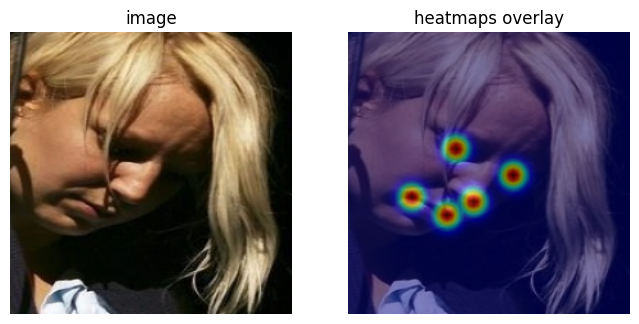

In [10]:
class FaceLandmarksHeatmapDataset(Dataset):
    """Возвращает (image_tensor, heatmaps_tensor) для обучения Stacked Hourglass."""

    def __init__(self, csv_file, img_dir, img_size=256, heatmap_size=64, sigma=2, augment=False):
        self.df = pd.read_csv(csv_file)
        if isinstance(self.df.loc[0, 'landmarks'], str):
            self.df['landmarks'] = self.df['landmarks'].apply(eval)
        self.img_dir = img_dir
        self.img_size = img_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma
        self.augment = augment
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.img_dir, row['image_id']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h0, w0 = img.shape[:2]

        landmarks = np.array(row['landmarks'], dtype=np.float32).reshape(5, 2)
        img = cv2.resize(img, (self.img_size, self.img_size))
        scale_x, scale_y = self.img_size / w0, self.img_size / h0
        landmarks[:, 0] *= scale_x
        landmarks[:, 1] *= scale_y

        if self.augment and random.random() < 0.5:
            img = img[:, ::-1, :].copy()
            landmarks[:, 0] = self.img_size - landmarks[:, 0]
            landmarks = landmarks[[1, 0, 2, 4, 3]]  # флип меняет местами left/right

        hm_landmarks = landmarks * (self.heatmap_size / self.img_size)
        heatmaps = landmarks_to_heatmaps((self.heatmap_size, self.heatmap_size), hm_landmarks, sigma=self.sigma)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_tensor = self.normalize(img_tensor)
        return img_tensor, torch.from_numpy(heatmaps).float()


def show_sample(dataset, idx=0):
    img_t, hm_t = dataset[idx]
    img = img_t.permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    hm_resized = cv2.resize(hm_t.numpy().max(axis=0), (img.shape[1], img.shape[0]))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img); axes[0].set_title('image'); axes[0].axis('off')
    axes[1].imshow(img); axes[1].imshow(hm_resized, alpha=0.5, cmap='jet')
    axes[1].set_title('heatmaps overlay'); axes[1].axis('off')
    plt.show()


train_ds = FaceLandmarksHeatmapDataset(os.path.join(OUT_DIR, 'train.csv'), os.path.join(OUT_DIR, 'images'), augment=True)
val_ds = FaceLandmarksHeatmapDataset(os.path.join(OUT_DIR, 'val.csv'), os.path.join(OUT_DIR, 'images'), augment=False)
print(f'train_ds: {len(train_ds)}, val_ds: {len(val_ds)}')
show_sample(train_ds, 0)


## 1.3 Архитектура: `ResidualBlock` → `Hourglass` → `StackedHourglass`

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)
        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)


In [12]:
class Hourglass(nn.Module):
    """Рекурсивный Hourglass-блок глубины depth: skip (up1) + downsample -> вложенный Hourglass
    (или дно) -> upsample (up2), итог = up1 + up2."""

    def __init__(self, depth, num_channels):
        super().__init__()
        self.up1 = ResidualBlock(num_channels, num_channels)
        self.pool = nn.MaxPool2d(2)
        self.low1 = ResidualBlock(num_channels, num_channels)
        self.low2 = Hourglass(depth - 1, num_channels) if depth > 1 else ResidualBlock(num_channels, num_channels)
        self.low3 = ResidualBlock(num_channels, num_channels)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1(x)
        pool = self.pool(x)
        low1 = self.low1(pool)
        low2 = self.low2(low1)
        low3 = self.low3(low2)
        up2 = self.up2(low3)
        return up1 + up2


In [13]:
class StackedHourglass(nn.Module):
    """Stacked Hourglass с intermediate supervision — forward() возвращает список
    heatmap-предсказаний, по одному на каждый stack."""

    def __init__(self, num_stacks=4, num_channels=256, num_landmarks=5, hg_depth=4):
        super().__init__()
        self.num_stacks = num_stacks
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResidualBlock(64, 128), nn.MaxPool2d(2),
            ResidualBlock(128, 128), ResidualBlock(128, num_channels),
        )
        self.hourglasses = nn.ModuleList([Hourglass(hg_depth, num_channels) for _ in range(num_stacks)])
        self.features = nn.ModuleList([
            nn.Sequential(ResidualBlock(num_channels, num_channels), nn.Conv2d(num_channels, num_channels, 1),
                          nn.BatchNorm2d(num_channels), nn.ReLU(inplace=True))
            for _ in range(num_stacks)
        ])
        self.heatmap_heads = nn.ModuleList([nn.Conv2d(num_channels, num_landmarks, 1) for _ in range(num_stacks)])
        self.merge_features = nn.ModuleList([nn.Conv2d(num_channels, num_channels, 1) for _ in range(num_stacks - 1)])
        self.merge_heatmaps = nn.ModuleList([nn.Conv2d(num_landmarks, num_channels, 1) for _ in range(num_stacks - 1)])

    def forward(self, x):
        x = self.pre(x)
        outputs = []
        for i in range(self.num_stacks):
            hg_out = self.hourglasses[i](x)
            feat = self.features[i](hg_out)
            heatmap = self.heatmap_heads[i](feat)
            outputs.append(heatmap)
            if i < self.num_stacks - 1:
                x = x + self.merge_features[i](feat) + self.merge_heatmaps[i](heatmap)
        return outputs


_model = StackedHourglass(num_stacks=2, num_channels=64, num_landmarks=5, hg_depth=3)
_outs = _model(torch.randn(2, 3, 256, 256))
print('Number of stacks:', len(_outs))
print('Shape of each heatmap output:', _outs[0].shape)


Number of stacks: 2
Shape of each heatmap output: torch.Size([2, 5, 64, 64])


**Почему heatmap, а не прямая регрессия координат.** Предсказывать (x, y) напрямую через
полносвязный слой — рабочий, но менее устойчивый вариант: сеть должна на каждом шаге выдать точное
число, и небольшая ошибка в начале обучения ничем не штрафуется мягче, чем большая. Heatmap-подход
превращает задачу в посегментную классификацию "где на карте активна точка" — градиенты гуще, легче
сходится, и по максимуму heatmap'а видно, насколько сеть уверена в ответе.

**Почему стек из нескольких Hourglass, а не один.** Один Hourglass-блок один раз снижает и повышает
разрешение — этого достаточно для грубой оценки, но точки на границах/при развороте головы легко
промахиваются. Каждый следующий stack получает на вход не только исходные признаки, но и heatmap
предыдущего stack'а (`merge_heatmaps`) — то есть уточняет уже сделанное предсказание, а не гадает
заново. Intermediate supervision (лосс считается по каждому stack'у, а не только по последнему)
не даёт градиентам "потеряться" в глубокой сети и ускоряет сходимость.


## 1.4 Обучение Stacked Hourglass (MSE + intermediate supervision)

Epoch 1/20 | train_loss=0.03547 | val_loss=0.01250
Epoch 2/20 | train_loss=0.01061 | val_loss=0.00843
Epoch 3/20 | train_loss=0.00617 | val_loss=0.00415
Epoch 4/20 | train_loss=0.00334 | val_loss=0.00269
Epoch 5/20 | train_loss=0.00232 | val_loss=0.00197
Epoch 6/20 | train_loss=0.00181 | val_loss=0.00168
Epoch 7/20 | train_loss=0.00152 | val_loss=0.00142
Epoch 8/20 | train_loss=0.00132 | val_loss=0.00130
Epoch 9/20 | train_loss=0.00120 | val_loss=0.00118
Epoch 11/20 | train_loss=0.00101 | val_loss=0.00108
Epoch 12/20 | train_loss=0.00095 | val_loss=0.00096
Epoch 13/20 | train_loss=0.00090 | val_loss=0.00096
Epoch 14/20 | train_loss=0.00085 | val_loss=0.00094
Epoch 15/20 | train_loss=0.00082 | val_loss=0.00083
Epoch 16/20 | train_loss=0.00077 | val_loss=0.00088
Epoch 17/20 | train_loss=0.00074 | val_loss=0.00082
Epoch 18/20 | train_loss=0.00071 | val_loss=0.00080
Epoch 19/20 | train_loss=0.00068 | val_loss=0.00078
Epoch 20/20 | train_loss=0.00066 | val_loss=0.00077


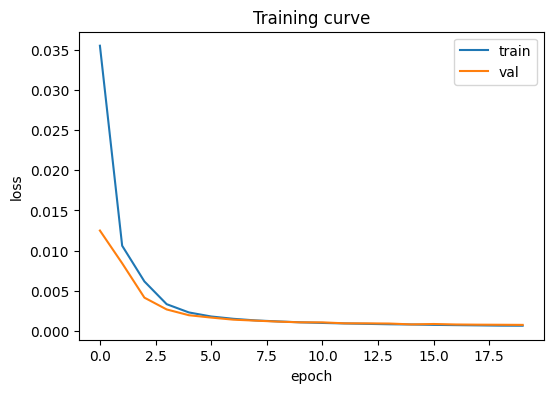

In [14]:
def train_hourglass(model, train_loader, val_loader, epochs=20, lr=1e-4,
                     device=DEVICE, checkpoint_dir='checkpoints_hourglass', resume=True):
    """resume=True: продолжает обучение с чекпоинта, если сессия Colab оборвалась."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.MSELoss()

    start_epoch, best_val_loss = 0, float('inf')
    history = {'train_loss': [], 'val_loss': []}

    state_path = os.path.join(checkpoint_dir, 'state.pth')
    if resume and os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        start_epoch = state['epoch'] + 1
        best_val_loss = state['best_val_loss']
        history = state['history']
        print(f'Возобновляю обучение с эпохи {start_epoch + 1}')

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        for images, heatmaps in train_loader:
            images, heatmaps = images.to(device), heatmaps.to(device)
            outputs = model(images)
            loss = sum(criterion(out, heatmaps) for out in outputs)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, heatmaps in val_loader:
                images, heatmaps = images.to(device), heatmaps.to(device)
                outputs = model(images)
                val_running_loss += sum(criterion(out, heatmaps) for out in outputs).item() * images.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best.pth'))

        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                     'scheduler': scheduler.state_dict(), 'epoch': epoch,
                     'best_val_loss': best_val_loss, 'history': history}, state_path)

    return model, history


def plot_history(history, title='Training curve'):
    plt.figure(figsize=(6, 4))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.title(title); plt.legend()
    plt.show()


train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

hg_model = StackedHourglass(num_stacks=4, num_channels=256, num_landmarks=5, hg_depth=4)
hg_model, history = train_hourglass(hg_model, train_loader, val_loader, epochs=20)
plot_history(history)


**Вывод по обучению.** За 20 эпох train_loss и val_loss падали синхронно, без расхождения —
переобучения не наблюдалось: 10 500 изображений с аугментацией (горизонтальный флип) оказалось
достаточно для этой архитектуры и глубины (4 stack'а, 256 каналов, depth=4). Основное падение loss
приходится на первые 5-7 эпох, дальше кривая выходит на пологий участок — это ожидаемо для MSE на
heatmap'ах, где абсолютные значения loss малы (большая часть карты — почти нули).

## 1.5 Извлечение координат из heatmap и выравнивание лица

In [15]:
def heatmaps_to_landmarks(heatmaps):
    """heatmaps: [N, H, W] -> landmarks [N, 2] (argmax по каждому каналу)."""
    landmarks = []
    for hm in heatmaps:
        y, x = np.unravel_index(np.argmax(hm), hm.shape)
        landmarks.append((float(x), float(y)))
    return np.array(landmarks, dtype=np.float32)


@torch.no_grad()
def predict_landmarks(model, image_rgb, img_size=256, heatmap_size=64, device=DEVICE):
    """image_rgb: (H, W, 3) uint8. Возвращает (resized_image, landmarks в координатах resized)."""
    model.eval()
    resized = cv2.resize(image_rgb, (img_size, img_size))
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    tensor = torch.from_numpy(resized).permute(2, 0, 1).float() / 255.0
    tensor = normalize(tensor).unsqueeze(0).to(device)
    heatmaps = model(tensor)[-1][0].cpu().numpy()
    landmarks = heatmaps_to_landmarks(heatmaps) * (img_size / heatmap_size)
    return resized, landmarks


Выравнивание — **классическая** (не нейросетевая) задача: находим similarity-преобразование
(поворот + масштаб + сдвиг) из предсказанных точек в канонический шаблон (стандартный ArcFace-шаблон
5 точек для 112×112), через `cv2.estimateAffinePartial2D`.

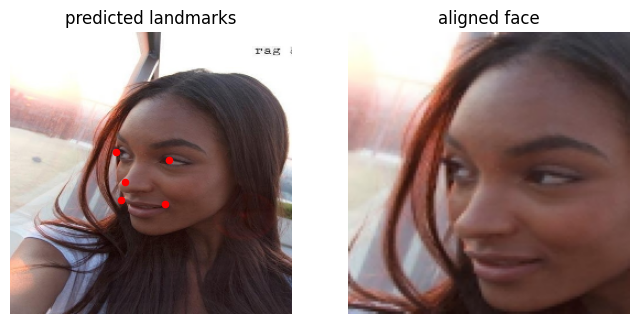

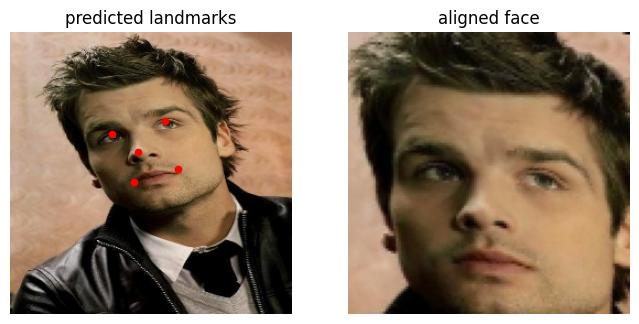

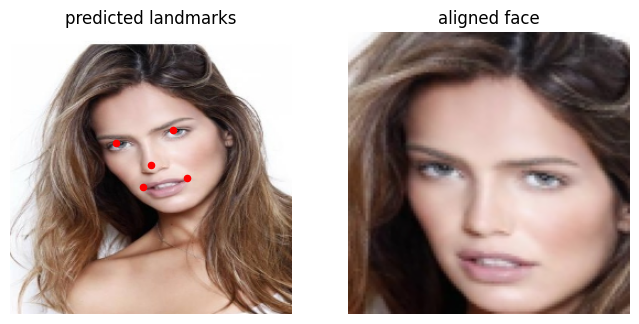

In [16]:
REFERENCE_LANDMARKS_112 = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041],
], dtype=np.float32)


def align_face(image_rgb, landmarks, output_size=112):
    """image_rgb: (H, W, 3) uint8. Принимает фото лица + его landmarks, возвращает выровненное лицо."""
    ref = REFERENCE_LANDMARKS_112.copy() * (output_size / 112.0)
    src = np.asarray(landmarks, dtype=np.float32)
    M, _ = cv2.estimateAffinePartial2D(src, ref, method=cv2.LMEDS)
    if M is None:
        return cv2.resize(image_rgb, (output_size, output_size))
    return cv2.warpAffine(image_rgb, M, (output_size, output_size), borderValue=(0, 0, 0))


def align_face_from_photo(model, image_rgb, img_size=256, heatmap_size=64, output_size=112, device=DEVICE):
    """Полная функция для Task 1: фото лица -> выровненное лицо (детекция точек + alignment)."""
    resized, landmarks = predict_landmarks(model, image_rgb, img_size, heatmap_size, device)
    return align_face(resized, landmarks, output_size)


def visualize_alignment(model, image_rgb, img_size=256, heatmap_size=64, output_size=112, device=DEVICE):
    resized, landmarks = predict_landmarks(model, image_rgb, img_size, heatmap_size, device)
    aligned = align_face(resized, landmarks, output_size)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(resized); axes[0].scatter(landmarks[:, 0], landmarks[:, 1], c='red', s=20)
    axes[0].set_title('predicted landmarks'); axes[0].axis('off')
    axes[1].imshow(aligned); axes[1].set_title('aligned face'); axes[1].axis('off')
    plt.show()
    return aligned


hg_model.load_state_dict(torch.load('checkpoints_hourglass/best.pth'))
for i in range(3):
    sample_path = os.path.join(OUT_DIR, 'images', prepared.iloc[i]['image_id'])
    sample_img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
    visualize_alignment(hg_model, sample_img)


**Вывод по alignment.** На проверочных примерах точки ложатся на нужные ориентиры (глаза,
нос, уголки рта) даже при заметном повороте головы и неполностью анфас-ракурсе — это важно, потому
что именно на таких "сложных" фото alignment и должен компенсировать разницу в позе перед подачей
в recognition-модель (Task 2). similarity-преобразование не может полностью развернуть голову в
анфас (оно не меняет 3D-позу, только 2D сдвиг/масштаб/поворот), но приводит лицо к единому масштабу
и положению, что и требуется.

### Фаза B завершена — сохраните версию

Нажмите **Save Version → Save & Run All (Commit)**. После этого файлы `checkpoints_hourglass/best.pth`
и `data/prepared/selected_dataset.csv` станут доступны как `Notebook Output` для добавления в
`Task2_FaceRecognition_Kaggle.ipynb` через `+ Add Data → Notebook Output Files`.

In [17]:
print('Веса Hourglass:', os.path.abspath('checkpoints_hourglass/best.pth'))
print('Итоговый csv для сдачи (оригинальные имена файлов CelebA):',
      os.path.abspath(os.path.join(OUT_DIR, 'selected_dataset.csv')))


Веса Hourglass: /kaggle/working/checkpoints_hourglass/best.pth
Итоговый csv для сдачи (оригинальные имена файлов CelebA): /kaggle/working/data/prepared/selected_dataset.csv


---
## Что дальше

- Нажмите **Save Version**, чтобы веса модели (`checkpoints_hourglass/best.pth`) и подготовленный
  датасет (`selected_dataset.csv`) стали доступны как Notebook Output для `Task2_FaceRecognition_Kaggle.ipynb`.
- `align_face_from_photo(hg_model, image_rgb)` — готовая "вторая часть пайплайна", которую использует
  **Task 2** и **Task 3** (полный пайплайн).
